In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [7]:
dataset = "../data/GTZAN/gtzan_with_lyrics_clean.csv"
images = "../data/GTZAN/images_original/"
audios = "../data/GTZAN/genres_original/"

In [8]:
# Load the dataset
df = pd.read_csv(dataset)
print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully!
Shape: (609, 6)

First few rows:


,ref,genre,songTitle,artistName,lyrics,lyrics_clean
0,blues.00000.wav,blues,"one bourbon, one scotch, one beer",john lee hooker,"[Chorus]\nOne bourbon, one scotch and one beer...",one bourbon one scotch and one beer one bourbo...
1,blues.00001.wav,blues,i'm in the mood,john lee hooker,[Chorus]\nI′m in the mood\nI'm in the mood for...,i′m in the mood i m in the mood for love every...
2,blues.00003.wav,blues,i'm bad like jesse james (live),john lee hooker,"Little thing I'm going to do called, ""I'm Bad ...",little thing i m going to do called i m bad li...
3,blues.00004.wav,blues,walkin' the boogie,john lee hooker,"Well my mama she didn't 'low me, just to stay ...",well my mama she didn low me just to stay ou...
4,blues.00005.wav,blues,sugar mama,john lee hooker,"Sugar mama, sugar mama, sugar mama please come...",sugar mama sugar mama sugar mama please come b...


In [9]:
# Basic Information
print("="*50)
print("DATASET OVERVIEW")
print("="*50)
df.info()
print("\n" + "="*50)
print("STATISTICAL SUMMARY")
print("="*50)
df.describe(include='all')

DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609 entries, 0 to 608
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ref           609 non-null    object
 1   genre         609 non-null    object
 2   songTitle     609 non-null    object
 3   artistName    609 non-null    object
 4   lyrics        609 non-null    object
 5   lyrics_clean  609 non-null    object
dtypes: object(6)
memory usage: 28.7+ KB

STATISTICAL SUMMARY


,ref,genre,songTitle,artistName,lyrics,lyrics_clean
count,609,609,609,609,609,609
unique,609,10,553,191,557,557
top,blues.00000.wav,rock,lady marmalade,bob marley & the wailers,"[Verse 1]\nBaby, I'm so into you\nYou got that...",baby i m so into you you got that something wh...
freq,1,95,3,30,3,3


MISSING VALUES ANALYSIS
         Column  Missing Count  Percentage
0           ref              0         0.0
1         genre              0         0.0
2     songTitle              0         0.0
3    artistName              0         0.0
4        lyrics              0         0.0
5  lyrics_clean              0         0.0


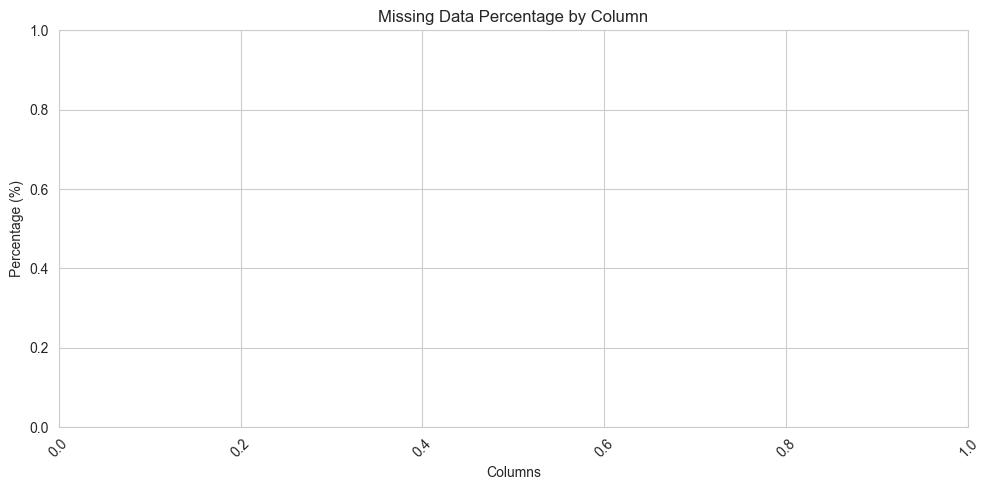

In [10]:
# Check for missing values
print("="*50)
print("MISSING VALUES ANALYSIS")
print("="*50)
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing Count': missing_data.values,
    'Percentage': missing_percent.values
})
print(missing_df)

# Visualize missing data
plt.figure(figsize=(10, 5))
plt.title('Missing Data Percentage by Column')
plt.ylabel('Percentage (%)')
plt.xlabel('Columns')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

GENRE DISTRIBUTION
genre
rock         95
metal        81
country      79
pop          78
hiphop       76
disco        73
reggae       71
blues        48
jazz          7
classical     1
Name: count, dtype: int64

Total genres: 10
Total songs: 609


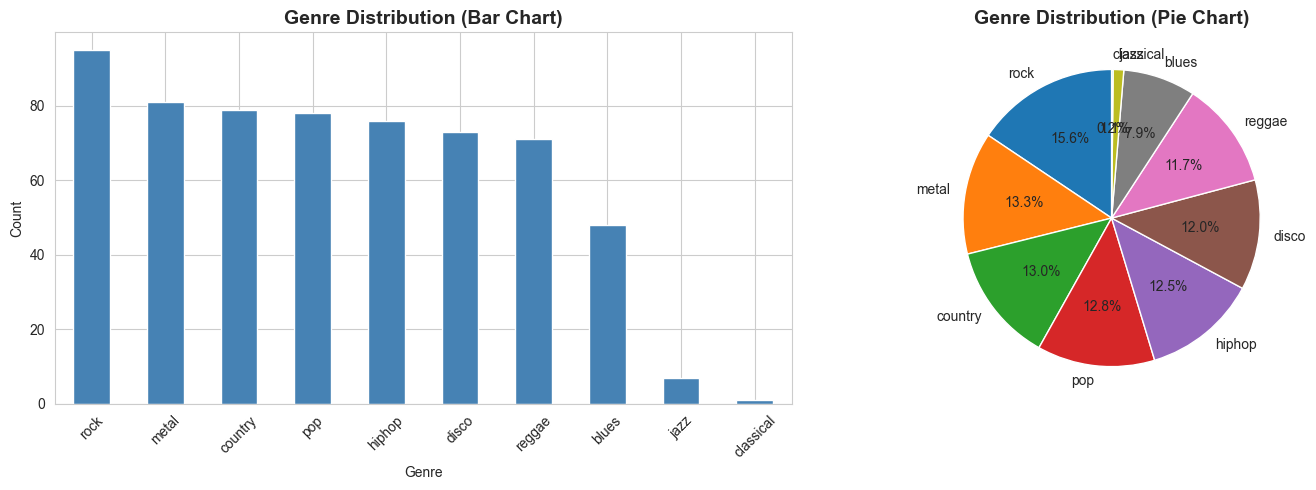

In [11]:
# Genre Distribution Analysis
print("="*50)
print("GENRE DISTRIBUTION")
print("="*50)
genre_counts = df['genre'].value_counts()
print(genre_counts)
print(f"\nTotal genres: {df['genre'].nunique()}")
print(f"Total songs: {len(df)}")

# Visualize genre distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
genre_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Genre Distribution (Bar Chart)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
axes[1].pie(genre_counts.values, labels=genre_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Genre Distribution (Pie Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [12]:
# Lyrics Analysis
print("="*50)
print("LYRICS ANALYSIS")
print("="*50)

# Filter rows with non-null lyrics_clean
df_with_lyrics = df[df['lyrics_clean'].notna()].copy()
print(f"Songs with lyrics: {len(df_with_lyrics)}")
print(f"Songs without lyrics: {len(df) - len(df_with_lyrics)}")

# Calculate lyrics length
df_with_lyrics['lyrics_length'] = df_with_lyrics['lyrics_clean'].str.len()
df_with_lyrics['word_count'] = df_with_lyrics['lyrics_clean'].str.split().str.len()

print(f"\nLyrics Length Statistics:")
print(df_with_lyrics['lyrics_length'].describe())
print(f"\nWord Count Statistics:")
print(df_with_lyrics['word_count'].describe())

LYRICS ANALYSIS
Songs with lyrics: 609
Songs without lyrics: 0

Lyrics Length Statistics:
count     609.000000
mean     1540.771757
std       942.477706
min        18.000000
25%       908.000000
50%      1274.000000
75%      1824.000000
max      6863.000000
Name: lyrics_length, dtype: float64

Word Count Statistics:
count     609.000000
mean      324.533662
std       195.930781
min         4.000000
25%       193.000000
50%       268.000000
75%       393.000000
max      1424.000000
Name: word_count, dtype: float64


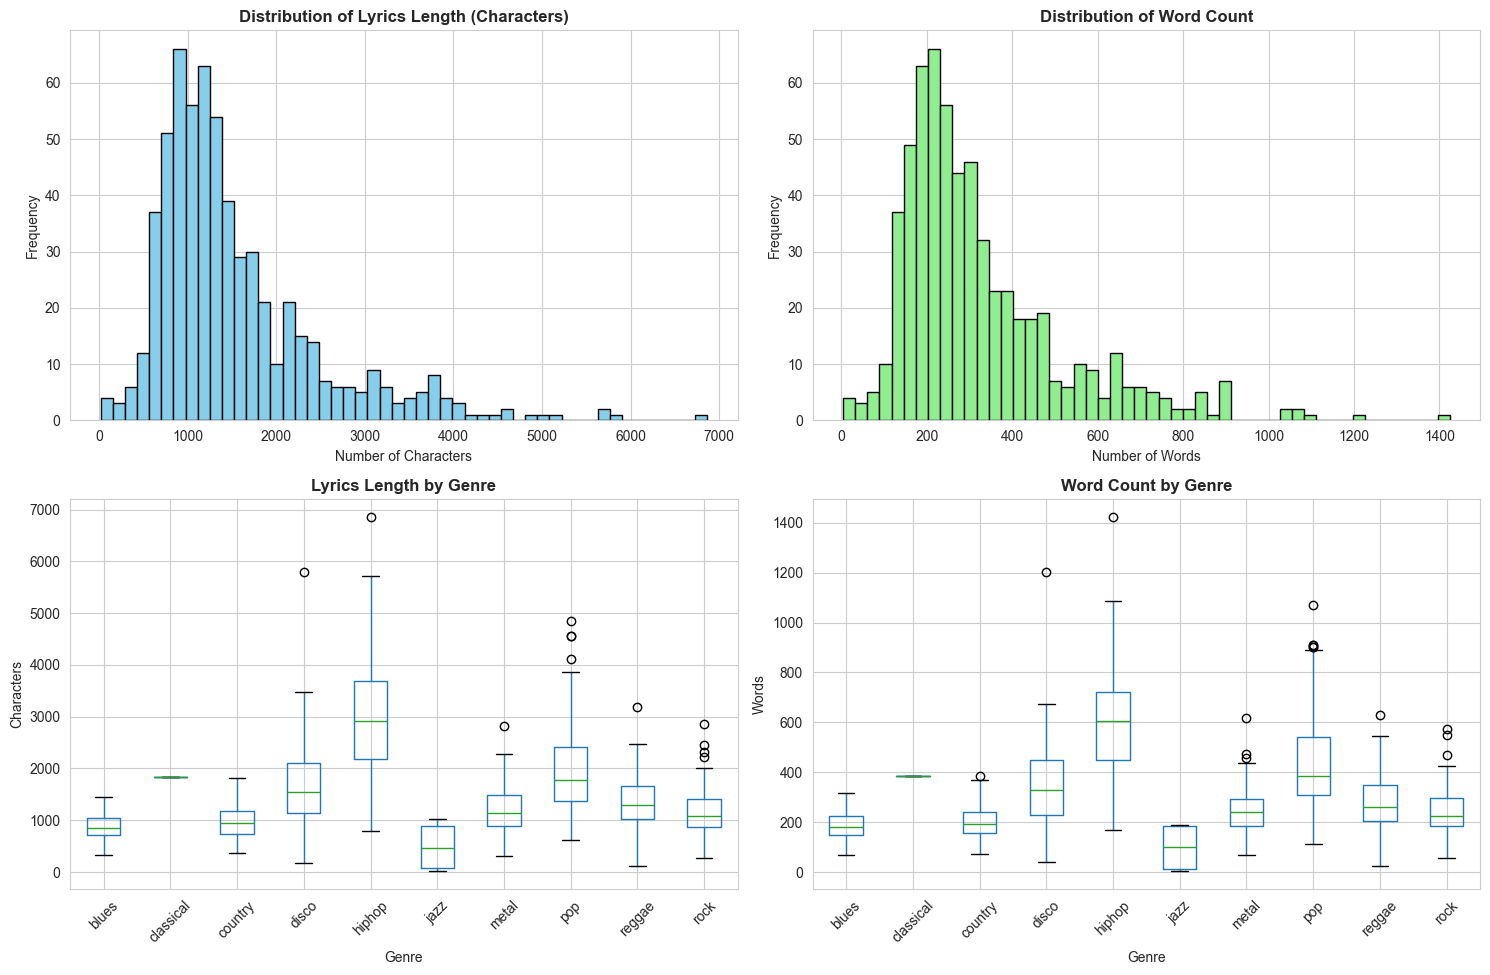

In [13]:
# Visualize lyrics length and word count distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Lyrics length histogram
axes[0, 0].hist(df_with_lyrics['lyrics_length'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Lyrics Length (Characters)', fontweight='bold')
axes[0, 0].set_xlabel('Number of Characters')
axes[0, 0].set_ylabel('Frequency')

# Word count histogram
axes[0, 1].hist(df_with_lyrics['word_count'], bins=50, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Distribution of Word Count', fontweight='bold')
axes[0, 1].set_xlabel('Number of Words')
axes[0, 1].set_ylabel('Frequency')

# Lyrics length by genre
df_with_lyrics.boxplot(column='lyrics_length', by='genre', ax=axes[1, 0])
axes[1, 0].set_title('Lyrics Length by Genre', fontweight='bold')
axes[1, 0].set_xlabel('Genre')
axes[1, 0].set_ylabel('Characters')
plt.sca(axes[1, 0])
plt.xticks(rotation=45)

# Word count by genre
df_with_lyrics.boxplot(column='word_count', by='genre', ax=axes[1, 1])
axes[1, 1].set_title('Word Count by Genre', fontweight='bold')
axes[1, 1].set_xlabel('Genre')
axes[1, 1].set_ylabel('Words')
plt.sca(axes[1, 1])
plt.xticks(rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.show()

LYRICS STATISTICS BY GENRE
          lyrics_length                  word_count               
                   mean  median      std       mean median     std
genre                                                             
blues            888.00   857.0   267.32     189.58  182.5   57.17
classical       1828.00  1828.0      NaN     384.00  384.0     NaN
country          971.53   949.0   305.59     206.75  193.0   66.53
disco           1679.40  1544.0   877.65     352.86  329.0  178.29
hiphop          2965.57  2913.5  1125.40     615.61  607.0  222.04
jazz             492.14   470.0   437.44      98.57  102.0   87.63
metal           1219.10  1144.0   462.78     250.78  240.0   95.41
pop             2065.69  1781.0   939.24     452.31  384.5  202.15
reggae          1363.34  1298.0   497.99     281.23  261.0  106.87
rock            1147.74  1084.0   450.81     242.41  226.0   93.31


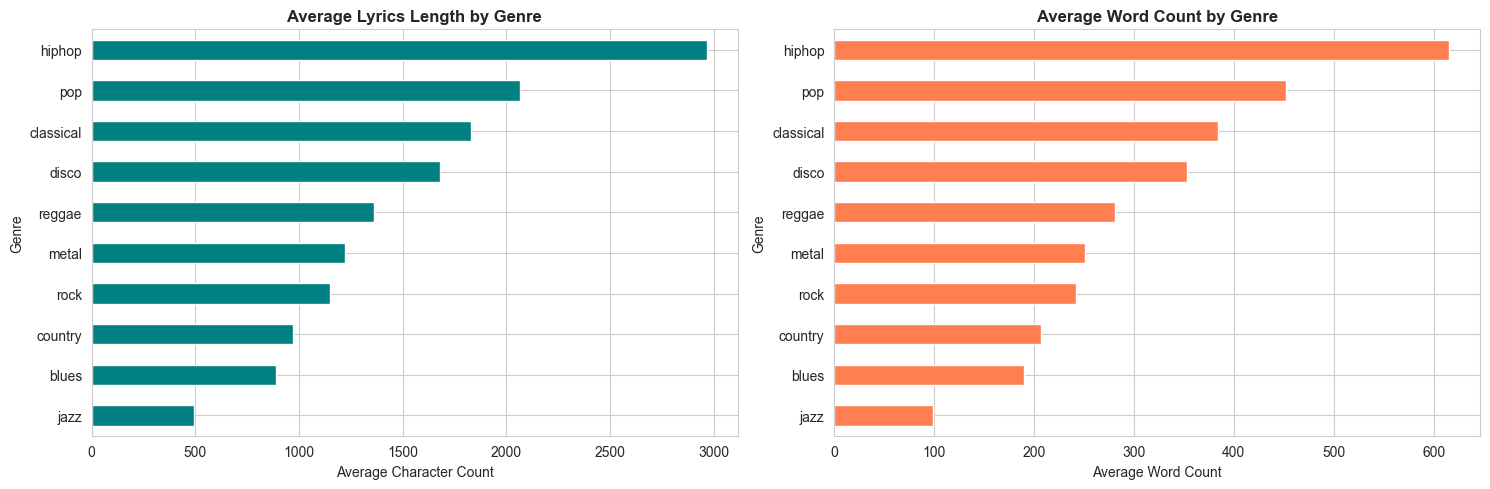

In [14]:
# Average lyrics statistics by genre
print("="*50)
print("LYRICS STATISTICS BY GENRE")
print("="*50)
genre_stats = df_with_lyrics.groupby('genre').agg({
    'lyrics_length': ['mean', 'median', 'std'],
    'word_count': ['mean', 'median', 'std']
}).round(2)
print(genre_stats)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

genre_avg = df_with_lyrics.groupby('genre')['lyrics_length'].mean().sort_values()
genre_avg.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Average Lyrics Length by Genre', fontweight='bold')
axes[0].set_xlabel('Average Character Count')
axes[0].set_ylabel('Genre')

genre_word_avg = df_with_lyrics.groupby('genre')['word_count'].mean().sort_values()
genre_word_avg.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Average Word Count by Genre', fontweight='bold')
axes[1].set_xlabel('Average Word Count')
axes[1].set_ylabel('Genre')

plt.tight_layout()
plt.show()

In [15]:
# Check file availability
print("="*50)
print("FILE AVAILABILITY CHECK")
print("="*50)

# Sample some files to check
sample_refs = df['ref'].head(10).tolist()
print(f"Checking sample audio and image files...\n")

for ref in sample_refs[:5]:
    genre = df[df['ref'] == ref]['genre'].values[0]
    audio_path = os.path.join(audios, genre, ref)
    image_path = os.path.join(images, genre, ref.replace('.wav', '.png'))
    
    audio_exists = os.path.exists(audio_path)
    image_exists = os.path.exists(image_path)
    
    print(f"File: {ref}")
    print(f"  Audio: {'✓' if audio_exists else '✗'} {audio_path}")
    print(f"  Image: {'✓' if image_exists else '✗'} {image_path}")
    print()

FILE AVAILABILITY CHECK
Checking sample audio and image files...

File: blues.00000.wav
  Audio: ✓ ../data/GTZAN/genres_original/blues\blues.00000.wav
  Image: ✗ ../data/GTZAN/images_original/blues\blues.00000.png

File: blues.00001.wav
  Audio: ✓ ../data/GTZAN/genres_original/blues\blues.00001.wav
  Image: ✗ ../data/GTZAN/images_original/blues\blues.00001.png

File: blues.00003.wav
  Audio: ✓ ../data/GTZAN/genres_original/blues\blues.00003.wav
  Image: ✗ ../data/GTZAN/images_original/blues\blues.00003.png

File: blues.00004.wav
  Audio: ✓ ../data/GTZAN/genres_original/blues\blues.00004.wav
  Image: ✗ ../data/GTZAN/images_original/blues\blues.00004.png

File: blues.00005.wav
  Audio: ✓ ../data/GTZAN/genres_original/blues\blues.00005.wav
  Image: ✗ ../data/GTZAN/images_original/blues\blues.00005.png



ARTIST & SONG ANALYSIS
Unique artists: 191
Unique songs: 553

Top 10 Artists by Song Count:
artistName
bob marley & the wailers    30
beastie boys                18
willie nelson               18
britney spears              18
robert johnson              16
a tribe called quest        15
vince gill                  14
queen                       14
public enemy                12
dio                         12
Name: count, dtype: int64


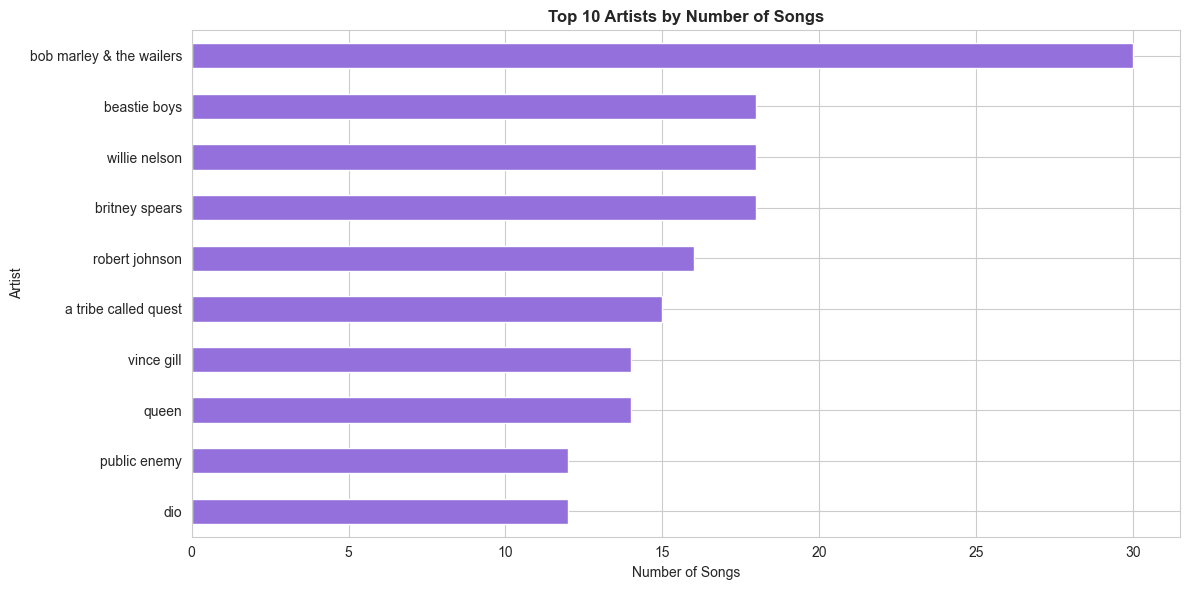

In [16]:
# Artist and Song Title Analysis
print("="*50)
print("ARTIST & SONG ANALYSIS")
print("="*50)

print(f"Unique artists: {df['artistName'].nunique()}")
print(f"Unique songs: {df['songTitle'].nunique()}")

# Top artists
print("\nTop 10 Artists by Song Count:")
top_artists = df['artistName'].value_counts().head(10)
print(top_artists)

# Visualize top artists
plt.figure(figsize=(12, 6))
top_artists.plot(kind='barh', color='mediumpurple')
plt.title('Top 10 Artists by Number of Songs', fontweight='bold')
plt.xlabel('Number of Songs')
plt.ylabel('Artist')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

WORD FREQUENCY ANALYSIS
Total unique words: 9199
Total words: 197641

Top 20 Most Common Words:
i: 8129
the: 7402
you: 7350
to: 3836
a: 3724
and: 3681
it: 3522
my: 2811
me: 2769
s: 2679
in: 2169
on: 2023
your: 2004
that: 1846
of: 1754
yeah: 1709
m: 1634
all: 1519
we: 1504
be: 1409


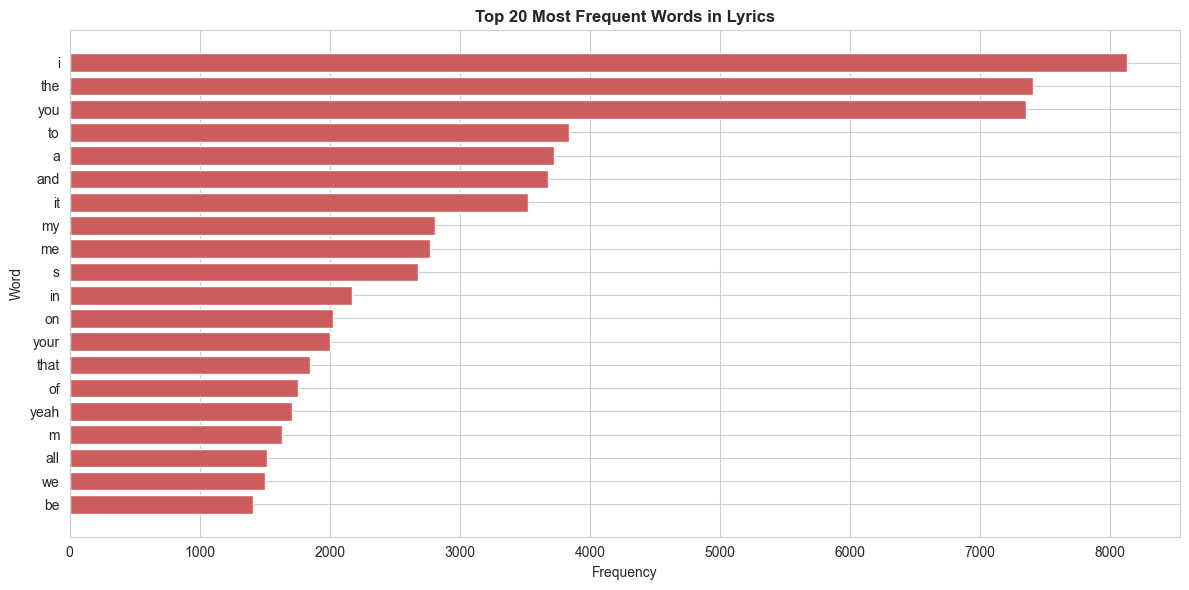

In [17]:
# Word frequency analysis across all lyrics
print("="*50)
print("WORD FREQUENCY ANALYSIS")
print("="*50)

# Combine all lyrics
all_lyrics = ' '.join(df_with_lyrics['lyrics_clean'].dropna().astype(str))
words = all_lyrics.split()

# Get word frequencies
word_freq = Counter(words)
print(f"Total unique words: {len(word_freq)}")
print(f"Total words: {len(words)}")

# Top 20 most common words
print("\nTop 20 Most Common Words:")
most_common = word_freq.most_common(20)
for word, count in most_common:
    print(f"{word}: {count}")

# Visualize top words
words_df = pd.DataFrame(most_common, columns=['Word', 'Frequency'])
plt.figure(figsize=(12, 6))
plt.barh(words_df['Word'], words_df['Frequency'], color='indianred')
plt.gca().invert_yaxis()
plt.title('Top 20 Most Frequent Words in Lyrics', fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

In [18]:
# Data quality checks
print("="*50)
print("DATA QUALITY CHECKS")
print("="*50)

# Check for duplicate songs
print(f"Duplicate refs: {df['ref'].duplicated().sum()}")
print(f"Duplicate song titles: {df['songTitle'].duplicated().sum()}")

# Check ref format
print(f"\nSample refs:")
print(df['ref'].head(10))

# Check if ref matches genre folder
print("\nGenre-Ref consistency check:")
sample_check = df.head(10)[['ref', 'genre']]
for idx, row in sample_check.iterrows():
    ref_genre = row['ref'].split('.')[0]
    matches = ref_genre == row['genre']
    print(f"{row['ref']} -> Genre: {row['genre']} {'✓' if matches else '✗'}")

DATA QUALITY CHECKS
Duplicate refs: 0
Duplicate song titles: 56

Sample refs:
0    blues.00000.wav
1    blues.00001.wav
2    blues.00003.wav
3    blues.00004.wav
4    blues.00005.wav
5    blues.00006.wav
6    blues.00007.wav
7    blues.00008.wav
8    blues.00010.wav
9    blues.00011.wav
Name: ref, dtype: object

Genre-Ref consistency check:
blues.00000.wav -> Genre: blues ✓
blues.00001.wav -> Genre: blues ✓
blues.00003.wav -> Genre: blues ✓
blues.00004.wav -> Genre: blues ✓
blues.00005.wav -> Genre: blues ✓
blues.00006.wav -> Genre: blues ✓
blues.00007.wav -> Genre: blues ✓
blues.00008.wav -> Genre: blues ✓
blues.00010.wav -> Genre: blues ✓
blues.00011.wav -> Genre: blues ✓


In [19]:
# Final Summary
print("="*50)
print("DATASET SUMMARY")
print("="*50)
print(f"Total Records: {len(df)}")
print(f"Total Genres: {df['genre'].nunique()}")
print(f"Genres: {', '.join(sorted(df['genre'].unique()))}")
print(f"\nTotal Unique Artists: {df['artistName'].nunique()}")
print(f"Total Unique Songs: {df['songTitle'].nunique()}")
print(f"\nRecords with Lyrics: {df['lyrics_clean'].notna().sum()}")
print(f"Records without Lyrics: {df['lyrics_clean'].isna().sum()}")
print(f"\nData Paths:")
print(f"  CSV: {dataset}")
print(f"  Audio: {audios}")
print(f"  Images: {images}")

DATASET SUMMARY
Total Records: 609
Total Genres: 10
Genres: blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, rock

Total Unique Artists: 191
Total Unique Songs: 553

Records with Lyrics: 609
Records without Lyrics: 0

Data Paths:
  CSV: ../data/GTZAN/gtzan_with_lyrics_clean.csv
  Audio: ../data/GTZAN/genres_original/
  Images: ../data/GTZAN/images_original/
